# Pre-analysis: unfiltered HMM hits in Actinobacteria

Loads every hmmsearch `.tblout` in `results/raw/Actinobacteria/` (no cutoff applied, so hits go down to
HMMER's default E = 10), combines them into one table, and looks at the bitscore distribution per model.

Two views per model:
- **all hits**: every protein reported, including weak hits to shared domains
- **best hit per genome**: the top-scoring protein in each genome, i.e. the candidate ortholog.
  Orthologs and non-orthologs usually form separate groups here, and a cutoff belongs in the gap between them.

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = "/vol/local/calarass/Projects/ara_comp_genomics/hmm_search"
RAW_DIR = f"{PROJECT_DIR}/results/raw/Actinobacteria"

# tblout columns (HMMER 3 --tblout); the last one, the description, can contain spaces
TBLOUT_COLS = [
    "target", "target_acc", "model", "model_acc",
    "evalue", "bitscore", "bias",
    "best_dom_evalue", "best_dom_bitscore", "best_dom_bias",
    "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc",
    "description",
]

BAR_COLOR = "#2a78d6"

## 1. Read each tblout and combine them

In [ ]:
def read_tblout(path):
    rows = []
    finished = False
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                if line.startswith("# [ok]"):
                    finished = True
                continue
            rows.append(line.rstrip("\n").split(maxsplit=len(TBLOUT_COLS) - 1))
    df = pd.DataFrame(rows, columns=TBLOUT_COLS)
    return df, finished


tables = []
unfinished = []
for path in sorted(glob.glob(f"{RAW_DIR}/*.tblout")):
    df, finished = read_tblout(path)
    genome = os.path.basename(path)[: -len(".tblout")]
    if not finished:
        unfinished.append(genome)
    df["genome"] = genome
    tables.append(df)

hit/s = pd.concat(tables, ignore_index=True)
for col in ["evalue", "bitscore", "bias", "best_dom_evalue", "best_dom_bitscore", "best_dom_bias", "exp"]:
    hits[col] = hits[col].astype(float)
hits["genus"] = hits.genome.str.split("_").str[0]

print(f"{len(tables)} tblout files, {len(hits)} hits in total")
print(f"genomes with no hits at all: {sum(len(t) == 0 for t in tables)}")
if unfinished:
    print("WARNING: these searches did not finish ('# [ok]' missing):", unfinished)
hits.head()

252 tblout files, 9070 hits in total
genomes with no hits at all: 0


,target,target_acc,model,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,...,reg,clu,ov,env,dom,rep,inc,description,genome,genus
0,Acidimicrobium_ferrooxidans_DSM_10331|AFER_RS1...,-,Conserved_SCO2401,-,1.500000e-06,24.1,0.0,9.100000e-06,21.5,0.0,...,1,1,0,1,1,1,1,synthase|WP_015798104.1,Acidimicrobium_ferrooxidans_DSM_10331,Acidimicrobium
1,Acidimicrobium_ferrooxidans_DSM_10331|AFER_RS0...,-,Conserved_SCO2402,-,1.700000e-30,103.1,9.2,6.500000e-30,101.2,9.2,...,1,1,0,1,1,1,1,alcohol dehydrogenase|WP_015798838.1,Acidimicrobium_ferrooxidans_DSM_10331,Acidimicrobium
2,Acidimicrobium_ferrooxidans_DSM_10331|AFER_RS0...,-,Conserved_SCO2402,-,4.600000e-17,58.9,13.5,7.500000e-17,58.2,13.5,...,1,1,0,1,1,1,1,alcohol dehydrogenase family protein|WP_015797...,Acidimicrobium_ferrooxidans_DSM_10331,Acidimicrobium
3,Acidimicrobium_ferrooxidans_DSM_10331|AFER_RS0...,-,Conserved_SCO2402,-,1.000000e-15,54.5,15.9,2.100000e-12,43.6,9.0,...,1,1,1,2,2,2,2,dehydrogenase catalytic domain-containing prot...,Acidimicrobium_ferrooxidans_DSM_10331,Acidimicrobium
4,Acidimicrobium_ferrooxidans_DSM_10331|AFER_RS0...,-,Conserved_SCO2402,-,1.300000e-12,44.3,18.3,1.100000e-08,31.4,12.1,...,1,1,1,2,2,2,2,oxidoreductase family protein|WP_015797671.1,Acidimicrobium_ferrooxidans_DSM_10331,Acidimicrobium


## 2. Keep the best hit per genome for each model

In [3]:
best = (hits.sort_values("bitscore", ascending=False)
            .drop_duplicates(["genome", "model"])
            .sort_values(["model", "bitscore"], ascending=[True, False]))

MODELS = sorted(hits.model.unique())
n_genomes = hits.genome.nunique()
print(f"{len(best)} best hits ({len(MODELS)} models x up to {n_genomes} genomes)")

1301 best hits (6 models x up to 252 genomes)


## 3. Bitscore summary per model

In [4]:
summary = pd.concat({
    "all hits": hits.groupby("model").bitscore.describe(),
    "best hit per genome": best.groupby("model").bitscore.describe(),
}, axis=1).round(1)
summary

all hits                                                 \
                     count   mean    std   min   25%   50%    75%     max   
model                                                                       
Conserved-SCO2407    270.0   94.3  140.5  10.8  26.9  39.2   50.7   766.7   
Conserved-SCO2408   1563.0   36.9   53.8   1.2  10.5  27.5   53.8  1273.0   
Conserved_SCO2401    934.0  103.4   91.5  10.3  35.3  86.4  133.8   803.4   
Conserved_SCO2402   3965.0   71.8   45.8   5.3  35.7  64.4  100.4   645.2   
Conserved_SCO2439    387.0   92.2   87.1   6.3  27.8  58.0  142.6   553.3   
Conserved_SCO2440   1951.0   89.6   52.1  10.1  48.9  95.3  124.6   497.2   

                  best hit per genome                                    \
                                count   mean    std   min    25%    50%   
model                                                                     
Conserved-SCO2407               189.0  108.6  151.9  10.8   30.8   41.1   
Conserved-SCO2408               250.0   91.8  111.3   8.2   63.6   73.2   
Conserved_SCO2401               226.0  151.9  140.8  11.9   41.8  128.7   
Conserved_SCO2402               248.0  150.4   79.7  12.6  118.5  137.1   
Conserved_SCO2439               156.0  149.4  101.1  12.3   56.8  153.4   
Conserved_SCO2440               232.0  142.0   76.8  11.5  110.7  140.2   

                                  
                     75%     max  
model                             
Conserved-SCO2407   54.3   766.7  
Conserved-SCO2408   85.9  1273.0  
Conserved_SCO2401  219.2   803.4  
Conserved_SCO2402  166.0   645.2  
Conserved_SCO2439  218.6   553.3  
Conserved_SCO2440  157.1   497.2

## 4. Bitscore distributions

Top row: all hits (y-axis in log scale, since weak hits dominate). Bottom row: best hit per genome.

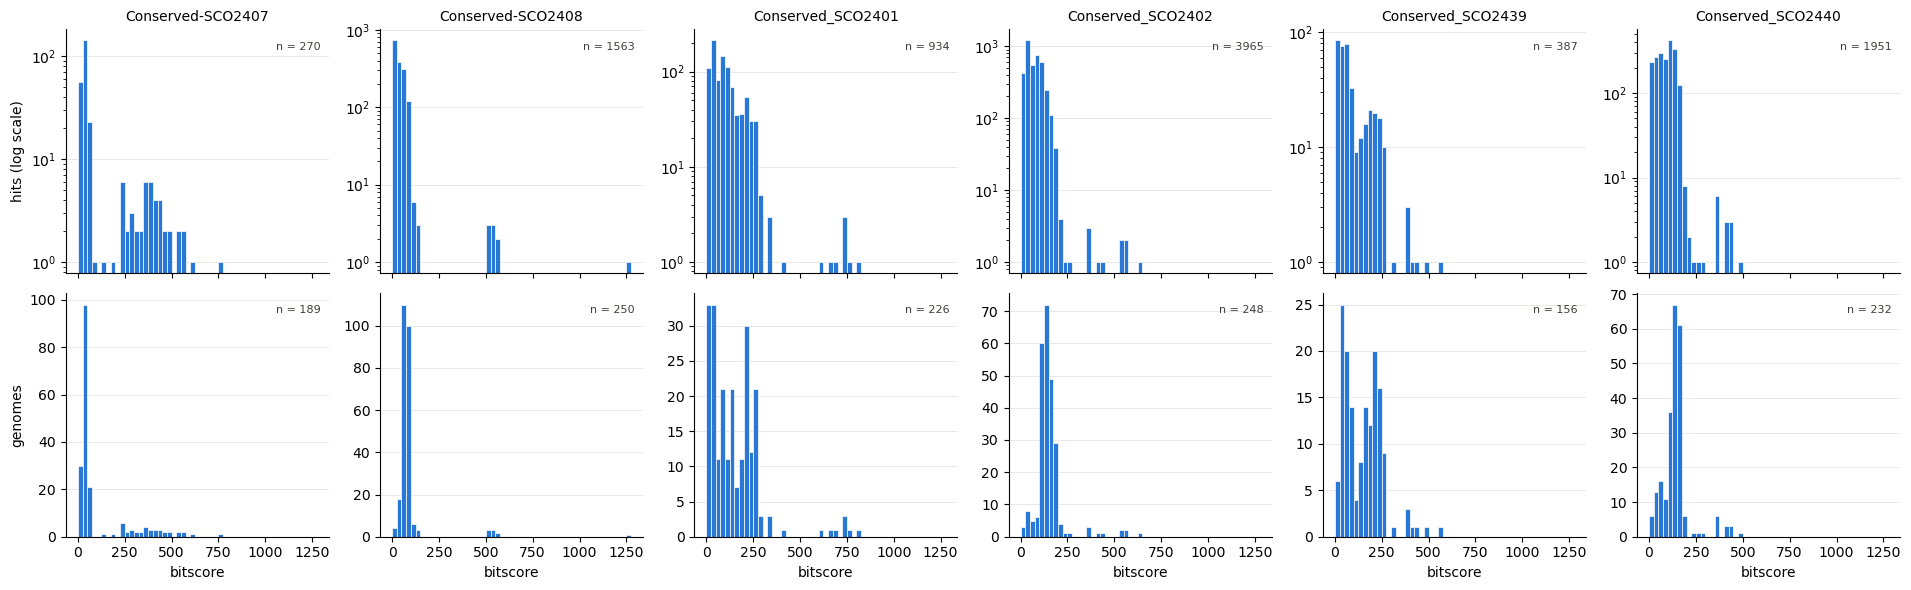

In [5]:
bins = np.arange(0, hits.bitscore.max() + 25, 25)

fig, axes = plt.subplots(2, len(MODELS), figsize=(3.2 * len(MODELS), 6), sharex=True)
for j, model in enumerate(MODELS):
    for i, (df, title) in enumerate([(hits, "all hits"), (best, "best hit per genome")]):
        ax = axes[i, j]
        scores = df.loc[df.model == model, "bitscore"]
        ax.hist(scores, bins=bins, color=BAR_COLOR, edgecolor="white", linewidth=0.5)
        if i == 0:
            ax.set_yscale("log")
            ax.set_title(model, fontsize=10)
        ax.text(0.97, 0.95, f"n = {len(scores)}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="#3d3d3a")
        ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    axes[1, j].set_xlabel("bitscore")

axes[0, 0].set_ylabel("hits (log scale)")
axes[1, 0].set_ylabel("genomes")
fig.tight_layout()
plt.show()

## 5. Look at a model more closely

Change `MODEL` and `MIN_SCORE` to list the best hits in a score range, e.g. to see which genomes sit in a group.

In [6]:
MODEL = MODELS[0]
MIN_SCORE, MAX_SCORE = 0, np.inf

best.loc[(best.model == MODEL) & best.bitscore.between(MIN_SCORE, MAX_SCORE),
         ["genome", "genus", "target", "bitscore", "evalue", "description"]]

,genome,genus,target,bitscore,evalue,description
8486,Streptomyces_coelicolor_A3(2),Streptomyces,Streptomyces_coelicolor_A3(2)|FQ762_RS12315|al...,766.7,1.700000e-231,epimerase family protein|WP_161270033.1
309,Actinocatenispora_sera,Actinocatenispora,Actinocatenispora_sera|Asera_RS31405|aldose,623.8,3.900000e-188,epimerase family protein|WP_030447205.1
4153,Kineococcus_radiotolerans_SRS30216_=_ATCC_BAA-149,Kineococcus,Kineococcus_radiotolerans_SRS30216_=_ATCC_BAA-...,552.6,1.200000e-166,epimerase family protein|WP_012085048.1
4308,Kribbella_flavida_DSM_17836,Kribbella,Kribbella_flavida_DSM_17836|KFLA_RS31500|aldose,550.7,6.500000e-166,epimerase family protein|WP_012923896.1
5071,Modestobacter_italicus,Modestobacter,Modestobacter_italicus|MODMU_RS11220|aldose,548.0,3.200000e-165,epimerase family protein|WP_014740354.1
...,...,...,...,...,...,...
5184,Mycobacterium_avium_subsp._paratuberculosis_K-10,Mycobacterium,Mycobacterium_avium_subsp._paratuberculosis_K-...,12.4,1.400000e-02,family protein|WP_003875101.1
4585,Leucobacter_triazinivorans,Leucobacter,Leucobacter_triazinivorans|EVS81_RS08215|FadR/...,11.4,2.000000e-02,family transcriptional regulator|WP_130109953.1
3326,Gephyromycinifex_aptenodytis,Gephyromycinifex,Gephyromycinifex_aptenodytis|G9V96_RS03120|aldose,11.3,2.100000e-02,1-epimerase family protein|WP_168581732.1
3812,Ilumatobacter_coccineus_YM16-304,Ilumatobacter,Ilumatobacter_coccineus_YM16-304|YM304_RS21990...,10.9,3.700000e-02,epimerase family protein|WP_015440491.1


In [7]:
# best-hit bitscore per genus for one model (distant genera score lower)
(best[best.model == MODEL]
     .groupby("genus").bitscore.agg(["count", "min", "median", "max"])
     .sort_values("median", ascending=False))

,count,min,median,max
genus,,,,
Actinocatenispora,1,623.8,623.8,623.8
Streptomyces,2,373.9,570.3,766.7
Kineococcus,1,552.6,552.6,552.6
Kribbella,1,550.7,550.7,550.7
Modestobacter,1,548.0,548.0,548.0
...,...,...,...,...
Acidimicrobium,1,12.8,12.8,12.8
Leucobacter,1,11.4,11.4,11.4
Gephyromycinifex,1,11.3,11.3,11.3


## 6. Comparison: Streptomycetae

Same loading and summary for `results/raw/Streptomycetae/`, to compare with the Actinobacteria table in section 3.

In [8]:
STREP_DIR = f"{PROJECT_DIR}/results/raw/Streptomycetae"

strep_tables = []
for path in sorted(glob.glob(f"{STREP_DIR}/*.tblout")):
    df, finished = read_tblout(path)
    if not finished:
        print("WARNING: search did not finish:", path)
    df["genome"] = os.path.basename(path)[: -len(".tblout")]
    strep_tables.append(df)

strep_hits = pd.concat(strep_tables, ignore_index=True)
strep_hits["bitscore"] = strep_hits.bitscore.astype(float)
strep_best = strep_hits.sort_values("bitscore", ascending=False).drop_duplicates(["genome", "model"])

print(f"{len(strep_tables)} tblout files, {len(strep_hits)} hits in total")

strep_summary = pd.concat({
    "all hits": strep_hits.groupby("model").bitscore.describe(),
    "best hit per genome": strep_best.groupby("model").bitscore.describe(),
}, axis=1).round(1)
strep_summary

207 tblout files, 14187 hits in total


all hits                                                  \
                     count   mean    std   min   25%    50%    75%     max   
model                                                                        
Conserved-SCO2407    455.0  318.7  273.1   5.1  13.7  383.2  446.3   769.3   
Conserved-SCO2408   2247.0   71.7  173.5   2.9  10.5   34.3   59.6  1273.0   
Conserved_SCO2401   1115.0  192.1  230.3  10.2  74.8  101.8  204.4   815.4   
Conserved_SCO2402   6291.0   81.6   85.6   5.1  36.6   62.6  104.9   646.4   
Conserved_SCO2439    559.0  163.7  197.9  11.7  29.0   52.8  218.6   553.3   
Conserved_SCO2440   3520.0  103.0   89.8   9.3  45.8   98.6  137.5   503.8   

                  best hit per genome                                     \
                                count   mean    std    min    25%    50%   
model                                                                      
Conserved-SCO2407               199.0  493.8  256.7   10.8  376.8  565.0   
Conserved-SCO2408               207.0  448.2  407.0   66.5   79.0   98.6   
Conserved_SCO2401               197.0  582.9  304.9   11.2  240.8  786.9   
Conserved_SCO2402               207.0  431.3  216.0  111.6  158.3  513.3   
Conserved_SCO2439               197.0  364.5  210.8   13.4   85.5  501.0   
Conserved_SCO2440               207.0  367.8  157.6  146.8  160.2  471.3   

                                  
                     75%     max  
model                             
Conserved-SCO2407  724.4   769.3  
Conserved-SCO2408  900.0  1273.0  
Conserved_SCO2401  803.6   815.4  
Conserved_SCO2402  633.4   646.4  
Conserved_SCO2439  529.7   553.3  
Conserved_SCO2440  494.7   503.8

Side by side: median and max of the best hit per genome.

In [9]:
pd.concat({
    "Actinobacteria": summary["best hit per genome"][["count", "50%", "max"]],
    "Streptomycetae": strep_summary["best hit per genome"][["count", "50%", "max"]],
}, axis=1)

Actinobacteria                Streptomycetae               
                           count    50%     max          count    50%     max
model                                                                        
Conserved-SCO2407          189.0   41.1   766.7          199.0  565.0   769.3
Conserved-SCO2408          250.0   73.2  1273.0          207.0   98.6  1273.0
Conserved_SCO2401          226.0  128.7   803.4          197.0  786.9   815.4
Conserved_SCO2402          248.0  137.1   645.2          207.0  513.3   646.4
Conserved_SCO2439          156.0  153.4   553.3          197.0  501.0   553.3
Conserved_SCO2440          232.0  140.2   497.2          207.0  471.3   503.8

## 7. Cutoffs from the Streptomycetae RBH comparison

Taken from `results/summary/hmm_vs_rbh_calls.tsv` (made by `07_compare_rbh.ipynb`), best HMM hit per genome:
- **trusted** = lowest-scoring RBH ortholog
- **noise** = highest-scoring non-ortholog

Rule per gene:
- `"trusted"`: cutoff = trusted. Used for SCO2402 and SCO2407, where orthologs and non-orthologs touch or overlap.
- `"noise+gap"`: cutoff = noise + `GAP_FRACTION` x (trusted - noise), i.e. a bit above the non-orthologs,
  leaving room for distant orthologs that score lower.

SCO2408 has no RBH data, so it gets no cutoff.
Note for SCO2401: its noise value comes from a single genome (*Peterkaempfera* sp., 641), which may be an ortholog
that RBH missed; the next non-ortholog is at ~423.

In [10]:
RBH_CALLS_FILE = f"{PROJECT_DIR}/results/summary/hmm_vs_rbh_calls.tsv"

CUTOFF_RULE = {
    "SCO2401": "noise+gap",
    "SCO2402": "trusted",
    "SCO2407": "trusted",
    "SCO2439": "noise+gap",
    "SCO2440": "noise+gap",
}
GAP_FRACTION = 0.25

rbh_calls = pd.read_csv(RBH_CALLS_FILE, sep="\t")

rows = []
for gene, s in rbh_calls.groupby("gene"):
    trusted = s.loc[s.rbh, "hmm_best_bitscore"].min()
    noise = s.loc[~s.rbh, "hmm_best_bitscore"].max()
    rule = CUTOFF_RULE[gene]
    cutoff = trusted if rule == "trusted" else noise + GAP_FRACTION * (trusted - noise)
    rows.append({"gene": gene, "noise": noise, "trusted": trusted, "gap": trusted - noise,
                 "rule": rule, "cutoff": round(cutoff, 1)})
cutoffs = pd.DataFrame(rows).set_index("gene")

# gene name for each model, e.g. Conserved_SCO2401 -> SCO2401
for df in (hits, best):
    df["gene"] = df.model.str.extract(r"(SCO\d+)", expand=False)
CUTOFF = cutoffs.cutoff.to_dict()
MODEL_GENE = dict(zip(hits.model, hits.gene))

cutoffs

,noise,trusted,gap,rule,cutoff
gene,,,,,
SCO2401,641.2,760.0,118.8,noise+gap,670.9
SCO2402,536.0,539.7,3.7,trusted,539.7
SCO2407,649.4,618.8,-30.6,trusted,618.8
SCO2439,270.8,446.7,175.9,noise+gap,314.8
SCO2440,281.7,430.1,148.4,noise+gap,318.8


## 9. Gap between the 1st and 2nd best hit within each genome

For every (genome, model): the three best-scoring proteins and the gap between the 1st and 2nd.

- big gap (e.g. 700 -> 200): one clear candidate
- small gap: two similar proteins in that genome (paralogs or duplicated copies), so the call is less certain

`hit2` / `hit3` are empty when the genome has fewer hits; the gap is then the full `hit1` score.
`passes` = `hit1_bitscore` >= the cutoff from section 7 (no cutoff for SCO2408).

In [12]:
TOP3_FILE = f"{PROJECT_DIR}/results/summary/actinobacteria_top3_hits.tsv"

ranked = hits.sort_values("bitscore", ascending=False).copy()
ranked["hit"] = ranked.groupby(["genome", "model"]).cumcount() + 1
ranked = ranked[ranked.hit <= 3]

top3 = ranked.pivot(index=["genome", "genus", "model"], columns="hit", values=["target", "bitscore"])
top3.columns = [f"hit{n}_{col}" for col, n in top3.columns]
top3 = top3.reset_index()[[
    "genome", "genus", "model",
    "hit1_target", "hit1_bitscore",
    "hit2_target", "hit2_bitscore",
    "hit3_target", "hit3_bitscore",
]]
top3["gap_1_2"] = top3.hit1_bitscore - top3.hit2_bitscore.fillna(0)
top3["cutoff"] = top3.model.map(MODEL_GENE).map(CUTOFF)
top3["passes"] = top3.hit1_bitscore >= top3.cutoff
top3 = top3.sort_values(["model", "hit1_bitscore"], ascending=[True, False]).reset_index(drop=True)

top3.to_csv(TOP3_FILE, sep="\t", index=False)
print(f"Wrote {len(top3)} rows to {TOP3_FILE}")

top3.groupby("model").agg(
    genomes=("genome", "size"),
    passing_cutoff=("passes", "sum"),
    median_gap_passing=("gap_1_2", lambda g: g[top3.loc[g.index, "passes"]].median()),
    median_gap_all=("gap_1_2", "median"),
).round(1)

Wrote 1301 rows to /vol/local/calarass/Projects/ara_comp_genomics/hmm_search/results/summary/actinobacteria_top3_hits.tsv


/tmp/ipykernel_544247/2027808237.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  top3["gap_1_2"] = top3.hit1_bitscore - top3.hit2_bitscore.fillna(0)


,genomes,passing_cutoff,median_gap_passing,median_gap_all
model,,,,
Conserved-SCO2407,189,2,464.6,33.3
Conserved-SCO2408,250,0,NaN,19.7
Conserved_SCO2401,226,6,484.1,38.9
Conserved_SCO2402,248,4,397.5,16.5
Conserved_SCO2439,156,7,327.8,65.6
Conserved_SCO2440,232,13,236.3,20.1


In [13]:
# one model at a time; set PASSING_ONLY = False to see every genome
MODEL = MODELS[0]
PASSING_ONLY = True

view = top3[top3.model == MODEL]
if PASSING_ONLY:
    view = view[view.passes]
view.drop(columns=["model", "cutoff"])

,genome,genus,hit1_target,hit1_bitscore,hit2_target,hit2_bitscore,hit3_target,hit3_bitscore,gap_1_2,passes
0,Streptomyces_coelicolor_A3(2),Streptomyces,Streptomyces_coelicolor_A3(2)|FQ762_RS12315|al...,766.7,Streptomyces_coelicolor_A3(2)|FQ762_RS12240|al...,438.5,NaN,NaN,328.2,True
1,Actinocatenispora_sera,Actinocatenispora,Actinocatenispora_sera|Asera_RS31405|aldose,623.8,Actinocatenispora_sera|Asera_RS01825|aldose,22.9,NaN,NaN,600.9,True


## 10. 1st vs 2nd best hit, plotted

Each point is a genome. Distance below the diagonal = the gap between the 1st and 2nd hit; points near the diagonal
have two similar proteins. Dashed line = cutoff.

/tmp/ipykernel_544247/3386687059.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ax.scatter(t.hit1_bitscore, t.hit2_bitscore.fillna(0), s=12, color=BAR_COLOR, edgecolor="white", linewidth=0.5)


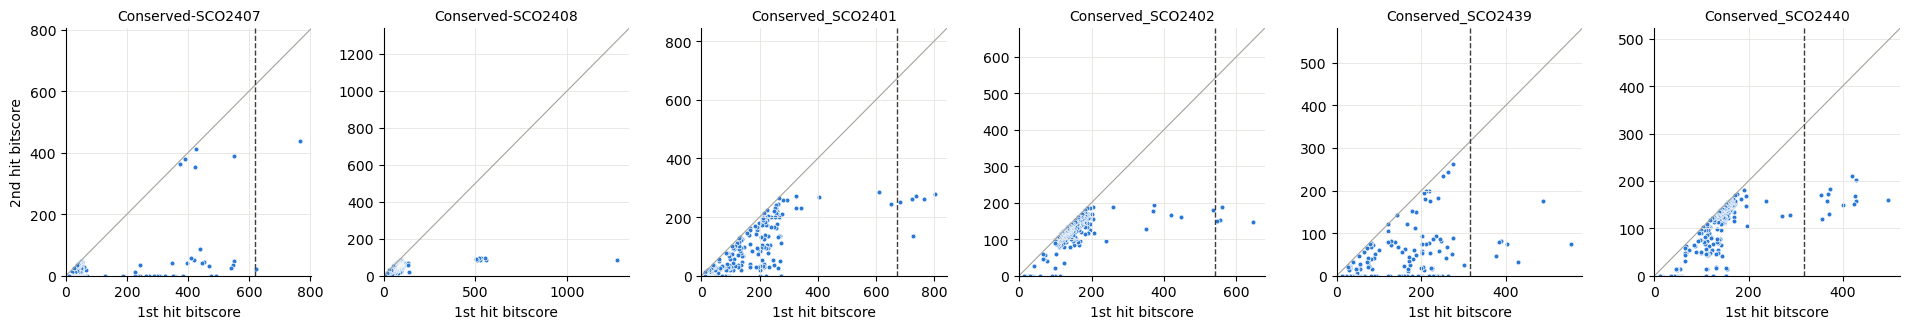

In [14]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(3.2 * len(MODELS), 3.4))
for ax, model in zip(axes, MODELS):
    t = top3[top3.model == model]
    ax.scatter(t.hit1_bitscore, t.hit2_bitscore.fillna(0), s=12, color=BAR_COLOR, edgecolor="white", linewidth=0.5)
    lim = t.hit1_bitscore.max() * 1.05
    ax.plot([0, lim], [0, lim], color="#a3a29b", linewidth=0.8)
    cutoff = CUTOFF.get(MODEL_GENE[model])
    if cutoff is not None:
        ax.axvline(cutoff, color="#3d3d3a", linestyle="--", linewidth=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_title(model, fontsize=10)
    ax.set_xlabel("1st hit bitscore")
    ax.grid(color="#e5e4df", linewidth=0.6)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("2nd hit bitscore")
fig.tight_layout()
plt.show()